## Zoonotic Potential

- [*] remember to turn of EC2 instance

#### Planning

#### Done

#### TODO


In [1]:
# Imports and config for the zoonotic-potential notebook

## Notebook config
import sys
if '../' not in sys.path:
    sys.path.append("../")
%load_ext dotenv
%reload_ext dotenv
%dotenv

import collections
import os
import urllib.parse
import csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

from datasources.neo4j import gds
from queries import utils

/home/ec2-user/miniconda3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configs

base_data_path = './zoonosis_data/'
virus_dataset = base_data_path + 'trefle/'
neo4j_data_path = base_data_path + 'neo4j/'
graphistry_data_path = base_data_path + 'graphistry/'
outputs = base_data_path + 'outputs/' 

print(gds)

stat_thresholds = [0.2, 0.5, 0.8]

df = pd.read_csv(virus_dataset + 'viruses.csv')

### Form zoonotic dataset


In [3]:
# Manually fill in any unresolved taxids
df2 = pd.read_csv(virus_dataset + 'species_taxids_patched.tsv', sep='\t', header=None, names=['name', 'taxid'])
df2['name'] = df2['name'].str.replace(' ', '_')
missing_taxid = df2[df2['taxid'].isna()]['name']

print(missing_taxid.shape)

merged = pd.merge(df, df2, left_on='vVirusNameCorrected', right_on='name', how='left')
merged = merged.drop(columns=['name'])
merged = merged.rename(columns={'taxid': 'TaxID'})
merged_dropna = merged.dropna(subset=['TaxID'])
merged_dropna['TaxIDInt'] = merged_dropna['TaxID'].astype(int)
merged_dropna['TaxID'] = merged_dropna['TaxID'].astype(str)
merged_dropna['vVirusNameDisplay'] = merged_dropna['vVirusNameCorrected'].str.replace('_', ' ',)

print(merged.shape)
print(merged_dropna.shape)
print()

print(merged_dropna['IsZoonotic'].value_counts())
print(merged_dropna['IsZoonotic.stringent'].value_counts())
print(merged_dropna['ReverseZoonoses'].value_counts())

(22,)
(586, 24)
(564, 26)

0    378
1    186
Name: IsZoonotic, dtype: int64
0    458
1    106
Name: IsZoonotic.stringent, dtype: int64
0    557
1      7
Name: ReverseZoonoses, dtype: int64


/tmp/ipykernel_28655/3934590257.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_dropna['TaxIDInt'] = merged_dropna['TaxID'].astype(int)
/tmp/ipykernel_28655/3934590257.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_dropna['TaxID'] = merged_dropna['TaxID'].astype(str)
/tmp/ipykernel_28655/3934590257.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

### Neo4j queries


#### Dataset Serratus overlap QA

Mapping tax_id to virus name:

- 586 virus in original dataset, 564 after parsing name to ncbi taxid, couldn't find 22 viruses in NCBI taxonomy. Of these 564, 378 are not zoonotic, 186 are zoonotic

Mapping SOTUs to virus tax_id

- Direct query of virus taxons from the dataset to mapped SOTUs results in coverage of 181 virus taxons (383 have no direct SOTUs). From these 181 virus taxons, there are 742 SOTU associations, max 215, mean ~4, std ~17. All of the SOTUs potential tax labels have strong percent identity and palmrint coverage (>= .95), i didn't account for e-values.
- Including all children and any parents with 'species' level rank from the virus taxons in the dataset does not increase the number of mapped virus taxons or SOTUs.

```
v1:
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (187, 7)
has_host_order_stat_edges:  (1346, 10)

v2 [threshold on STAT @ 0.2]:
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (281, 7)
has_host_order_stat_edges:  (2950, 10)

v3 [threshold on STAT @ 0.5]:
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (231, 7)
has_host_order_stat_edges:  (1642, 10)

v4 [threshold on STAT @ 0.9]
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (167, 7)
has_host_order_stat_edges:  (877, 10)
```


In [26]:
query_sotu_nodes = """
    MATCH (a:SOTU)-[:HAS_POTENTIAL_TAXON]->(b:Taxon)
    WHERE b.taxId in $tax_ids
    RETURN
        id(a) as nodeId,
        a.palmId as appId,
        a.palmId as palmId,
        labels(a) as labels,
        b.taxId as taxId,
        b.rank as taxRank,
        b.taxOrder as taxOrder,
        CASE WHEN b.taxId in $zoonotic_tax_ids THEN True ELSE False END AS isZoonotic
"""

query_sotu_msa_edges = """
    MATCH (a:SOTU)-[r:SEQUENCE_ALIGNMENT]->(b:SOTU)
    WHERE a.palmId in $sotus
    AND b.palmId in $sotus
    RETURN
        id(a) as sourceNodeId,
        a.palmId as sourceAppId,
        id(b) as targetNodeId,
        b.palmId as targetAppId,
        'SEQUENCE_ALIGNMENT' as relationshipType,
        r.percentIdentity as percentIdentity,
        r.percentIdentity as weight
"""

query_stat_taxon_order_nodes = """
    CALL {
        MATCH (p:SOTU)<-[:HAS_SOTU]-(:Palmprint)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->()-[:HAS_PARENT*0..]->(t:Taxon {rank: 'order'})
        WHERE p.palmId in $sotus
        AND q.percentIdentity >= $stat_threshold
        OPTIONAL MATCH (t)-[:HAS_PARENT*0..]->(u:Taxon)
        WHERE u.taxId in $host_class_tax_ids
        RETURN t, u
        UNION
        MATCH (p:SOTU)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->()-[:HAS_PARENT*0..]->(t:Taxon {rank: 'order'})
        WHERE p.palmId in $sotus
        AND q.percentIdentity >= $stat_threshold
        OPTIONAL MATCH (t)-[:HAS_PARENT*0..]->(u:Taxon)
        WHERE u.taxId in $host_class_tax_ids
        RETURN t, u
    }
    WITH t, u
    RETURN
        id(t) as nodeId,
        t.taxId as appId,
        t.taxId as taxId,
        labels(t) as labels,
        t.rank as taxRank,
        t.taxOrder as taxOrder,        
        CASE WHEN u.taxId = '40674' THEN 'Mammal' ELSE 
            CASE WHEN u.taxId = '33090' THEN 'Plant' ELSE 
                CASE WHEN u.taxId = '4751' THEN 'Fungi' ELSE 
                    CASE When u.taxId = '33630' THEN 'Parasite' ELSE 
                         CASE WHEN (u.taxId = '1476529' OR u.taxId = '7777' OR u.taxID = '1476750' OR u.taxId = '7742') THEN 'Fish-like' ELSE
                            CASE WHEN u.taxId = '10239' THEN 'Virus' ELSE 
                                CASE WHEN u.taxId = '6656' THEN 'Anthropod' ELSE 
                                    CASE WHEN u.taxId = '2' THEN 'Bacteria' ELSE
                                        'Other'
                                    END
                                END
                            END
                        END
                    END
                END
            END
        END AS hostClass
"""

query_has_host_order_stat = '''
    CALL {
        MATCH (p:SOTU)<-[:HAS_SOTU]-(:Palmprint)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->()-[:HAS_PARENT*0..]->(t:Taxon {rank: 'order'})
        WHERE p.palmId in $sotus
        AND q.percentIdentity >= $stat_threshold
        RETURN p, t, r, q
        UNION
        MATCH (p:SOTU)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->()-[:HAS_PARENT*0..]->(t:Taxon {rank: 'order'})
        WHERE p.palmId in $sotus
        AND q.percentIdentity >= $stat_threshold
        RETURN p, t, r, q
    }
    WITH p, t, r, q
    RETURN
        id(p) as sourceNodeId,
        p.palmId as sourceAppId,
        id(t) as targetNodeId,
        t.taxId as targetAppId,
        //CASE WHEN percentIdentityFull >= 0.2 THEN id(t) ELSE 8765758 END AS targetNodeId,
        //CASE WHEN percentIdentityFull >= 0.2 THEN t.taxId ELSE '12908' END AS targetAppId,
        'HAS_HOST_STAT' as relationshipType,
        count(*) AS count,
        avg(r.percentIdentity) as avgPercentIdentityPalmprint,
        avg(q.percentIdentity) as avgPercentIdentityStatKmers,
        avg(q.percentIdentityFull) as avgPercentIdentityStatSpots,
        avg(q.percentIdentity) * avg(r.percentIdentity) as weight
'''

query_sotu_has_cluster = '''
    MATCH (a:SOTU)-[r:SEQUENCE_ALIGNMENT]->(b:SOTU)
    WHERE a.palmId in $sotus
    AND r.percentIdentity >= $cluster_threshold
    RETURN
        id(a) as sourceNodeId,
        a.palmId as sourceAppId,
        id(b) as targetNodeId,
        b.palmId as targetAppId,
        'HAS_SOTU_CLUSTER' as relationshipType,
        r.percentIdentity as percentIdentity,
        r.percentIdentity as weight
'''


query_has_host_metadata_label = """
    CALL {
        MATCH (p:SOTU)<-[:HAS_SOTU]-(:Palmprint)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST]->(t:Taxon)
        WHERE p.palmId in $sotus
        RETURN p, t, r, q
        UNION
        MATCH (p:SOTU)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST]->(t:Taxon)
        WHERE p.palmId in $sotus
        RETURN p, t, r, q
    }
    WITH p, t, r, q, avg(q.percentIdentityFull) as percentIdentityFull
    RETURN
        id(p) as sourceNodeId,
        p.palmId as sourceAppId,
        id(t) as targetNodeId,
        t.taxId as targetAppId,
        'HAS_HOST_METADATA_LABEL' as relationshipType,
        count(*) AS count,
        avg(q.percentIdentityFull) as avgPercentIdentityStatSpots,
        1 as weight
"""

query_SOTU_SRA_BP_counts = """
    CALL {
        MATCH (p:SOTU)<-[:HAS_SOTU]-(:Palmprint)<-[r:HAS_PALMPRINT]-(s:SRA)
        WHERE p.palmId in $sotus
        RETURN p, r, s
        UNION
        MATCH (p:SOTU)<-[r:HAS_PALMPRINT]-(s:SRA)
        WHERE p.palmId in $sotus
        RETURN p, r, s
    }
    WITH p, r, s
    RETURN
        id(p) as sourceNodeId,
        p.palmId as sourceAppId,
        count(distinct s) as countSRA,
        count(distinct s.bioProject) as countBioProject
"""

query_SOTU_vertebrates = """
    CALL {
        MATCH (p:SOTU)<-[:HAS_SOTU]-(:Palmprint)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->()-[:HAS_PARENT*0..]->(t:Taxon {rank: 'order'})
        WHERE p.palmId in $sotus
        AND q.percentIdentity >= $stat_threshold
        OPTIONAL MATCH (t)-[:HAS_PARENT*0..]->(u:Taxon)
        WHERE u.taxId = '7742'
        RETURN t, u
        UNION
        MATCH (p:SOTU)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->()-[:HAS_PARENT*0..]->(t:Taxon {rank: 'order'})
        WHERE p.palmId in $sotus
        AND q.percentIdentity >= $stat_threshold
        OPTIONAL MATCH (t)-[:HAS_PARENT*0..]->(u:Taxon)
        WHERE u.taxId = '7742'
        RETURN t, u
    }
    WITH t, u
    RETURN
        id(t) as nodeId,
        t.taxId as appId,
        t.taxId as taxId,
        labels(t) as labels,
        t.rank as taxRank,
        t.taxOrder as taxOrder,        
        CASE WHEN u.taxId = '7742' THEN True ELSE False END AS isVertebrate 
"""

query_sotu_num_palmprints = """
    MATCH (a:SOTU)<-[r:HAS_SOTU*0..1]-(b:Palmprint)
    RETURN
        id(a) as nodeId,
        a.palmId as appId,
        a.palmId as palmId,
        count(r) as numPalmprints
"""


In [5]:
### QA queries

query_has_host_stat = '''
    CALL {
        MATCH (p:SOTU)<-[:HAS_SOTU]-(:Palmprint)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->(t:Taxon)
        WHERE p.palmId in $sotus
        RETURN p, t, r, q
        UNION
        MATCH (p:SOTU)<-[r:HAS_PALMPRINT]-(s:SRA)
            -[q:HAS_HOST_STAT]->(t:Taxon)
        WHERE p.palmId in $sotus
        RETURN p, t, r, s, q
    }
    WITH p, t, r, s, q, avg(q.percentIdentityFull) as percentIdentityFull
    RETURN
        id(p) as sourceNodeId,
        p.palmId as sourceAppId,
        CASE WHEN percentIdentityFull >= 0.2 THEN id(t) ELSE 8765758 END AS targetNodeId,
        CASE WHEN percentIdentityFull >= 0.2 THEN t.taxId ELSE '12908' END AS targetAppId,
        'HAS_HOST_STAT' as relationshipType,
        count(*) AS directAssociations,
        count(*) AS count,
        avg(r.percentIdentity) as avgPercentIdentityPalmprint,
        avg(q.percentIdentity) as avgPercentIdentityStatKmers,
        avg(q.percentIdentityFull) as avgPercentIdentityStatSpots,
        avg(q.percentIdentity) * avg(r.percentIdentity) as weight
'''

query_tax_ids_exist = """
    MATCH (a:Taxon)
    WHERE a.taxId in $tax_ids
    RETURN COLLECT(DISTINCT a.taxId) as tax_ids
"""

query_palmprint_exists = """
    CALL {
        MATCH (a:SOTU)-[:HAS_POTENTIAL_TAXON]->(b:Taxon)
        WHERE b.taxId in $tax_ids
        RETURN b.taxId as tax_id, COLLECT(DISTINCT a.palmId) as palmprints
        UNION
        MATCH (a:SOTU)<-[:HAS_SOTU*]-(b:Palmprint)-[:HAS_POTENTIAL_TAXON]->(c:Taxon)
        WHERE c.taxId in $tax_ids
        RETURN b.taxId as tax_id, COLLECT(DISTINCT a.palmId) + COLLECT(DISTINCT b.palmId) as palmprints
    }
    WITH tax_id, palmprints
    RETURN
        tax_id,
        palmprints
"""

query_sotus_exist_parent_child = """
    CALL {
        MATCH (a:SOTU)-[:HAS_POTENTIAL_TAXON]->(b:Taxon)
        WHERE b.taxId in $tax_ids
        RETURN b.taxId as tax_id, COLLECT(DISTINCT a.palmId) as sotus
        UNION
        MATCH (a:Taxon)<-[:HAS_PARENT*]-(b:Taxon)<-[:HAS_POTENTIAL_TAXON]-(c:SOTU)
        WHERE a.taxId in $tax_ids
        RETURN b.taxId as tax_id, COLLECT(DISTINCT a.palmId) as sotus
        UNION
        MATCH (a:Taxon)-[:HAS_PARENT*]->(b:Taxon)<-[:HAS_POTENTIAL_TAXON]-(c:SOTU)
        WHERE a.taxId in $tax_ids
        AND b.rank = 'species'
        RETURN b.taxId as tax_id, COLLECT(DISTINCT a.palmId) as sotus
    }
    WITH tax_id, sotus
    RETURN
        tax_id,
        sotus
"""

### Create Neo4j dataframes


In [6]:
# Logging helpers
def _log_df(df):
    namespace = globals()
    var_name = [name for name in namespace if namespace[name] is df]
    print(var_name, df.shape)
    print(df.head())

def _log_graph_shape(neo4j_data):
    print(neo4j_data['has_host_order_stat_edges']['targetAppId'].unique().shape)
    print(neo4j_data['has_host_class_label_map']['taxId'].unique().shape)
    print(neo4j_data['has_host_class_label_map']['hostClass'].value_counts())


def _log_missing_nodes(neo4j_data):
    # TODO: look into why some virus taxons in dataset have no matching SOTUs
    # ex: https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/wwwtax.cgi?mode=Info&id=11856&lvl=3&lin=f&keep=1&srchmode=1&unlock
    # exists in genbank, check for any SOTUs mapped to genbank id?
    missing_tax_ids = set(tax_ids) - set(neo4j_data['sotu_nodes']['taxId'].astype(str))
    print(f"Total virus tax_ids in dataset: {len(set(tax_ids))}")
    print(f"Total SOTUs matching virus tax_ids in neo4j: {len(set(neo4j_data['sotu_nodes']['taxId']))}")
    print(f"SOTUs missing virus tax_ids in neo4j: {len(missing_tax_ids)}")
    print()

    # TODO: look into why some SOTUs have no host order stat edges
    # Verify all/most are metagenomic, still, they should not be included as SOTUs 
    print(f"Total SOTUs: {len(neo4j_data['sotu_nodes']['appId'].unique())}")
    print(f"SOTUs with host order stat edges: {len(neo4j_data['has_host_order_stat_edges']['sourceAppId'].unique())}")
    sotus_missing_host = neo4j_data['sotu_nodes'].loc[~neo4j_data['sotu_nodes']['appId'].isin(neo4j_data['has_host_order_stat_edges']['sourceAppId'])]['appId'].unique()
    print(f"SOTUs missing host order stat edges: {len(sotus_missing_host)}")

In [27]:
# Run neo4j queries or load from cache
tax_ids = list(merged_dropna.TaxID.unique())
zoonotic_tax_ids = list(merged_dropna[merged_dropna['IsZoonotic'] == True].TaxID.unique())
host_class_tax_ids = [
    '40674', # [Mammal] Mammalia
    '33090', # [Plant], Viridiplantae
    '4751', # [Fungi]
    '33630', # [Parasite], Alveolata
    '2', # [Bacteria]
    '10239', # [Virus], Viruses
    '6656', # [Anthropod], Arthropoda
    '7742' # [Fish], Vertabrata 
    '1476529', # [Fish], Cyclostomata 
    '7777' # [Fish], Chondrichthyes
    '1476750', # [Fish], fish environmental sample
    # '12908', # [Metagenome], Unclassified / Metagenome
]


def fetch_cached_df(query, params, filename, use_cache=True, log=False):
    if os.path.exists(neo4j_data_path + filename) and use_cache:
        df = pd.read_csv(neo4j_data_path + filename)
        df = utils.deserialize_df(df)
    else:
        df = gds.run_cypher(query, params=params)
        df.to_csv(neo4j_data_path + filename, index=False)
    if log:
        _log_df(df)
    return df


def get_neo4j_data(stat_threshold=0.8, cluster_threshold=0.8):
    sotu_nodes = fetch_cached_df(
        query_sotu_nodes,
        {
            'tax_ids': tax_ids,
            'zoonotic_tax_ids': zoonotic_tax_ids,
        },
        f"{stat_threshold}/n4j_sotu_nodes.csv",
    )
    sotus = sotu_nodes['palmId'].unique().tolist()
    sotu_msa_edges = fetch_cached_df(
        query_sotu_msa_edges,
        {
            'tax_ids': tax_ids,
            'sotus': sotus,
        },
        f"{stat_threshold}/n4j_sotu_msa_edges.csv",
    )
    sotu_nodes['taxId'] = sotu_nodes['taxId'].astype(int)

    taxon_order_nodes = fetch_cached_df(
        query_stat_taxon_order_nodes,
        {
            'sotus': sotus,
            'host_class_tax_ids': host_class_tax_ids,
            'stat_threshold': stat_threshold,
        },
        f"{stat_threshold}/n4j_taxon_order_nodes.csv",
    )
    taxon_order_nodes['taxId'] = taxon_order_nodes['taxId'].astype(int)
    taxon_order_nodes['appId'] = taxon_order_nodes['appId'].astype(int)
    # taxon_order_nodes = taxon_order_nodes.drop_duplicates(subset=['taxId'], keep='last')

    has_host_order_stat_edges = fetch_cached_df(
        query_has_host_order_stat,
        {
            'sotus': sotus,
            'stat_threshold': stat_threshold,
        },
        f"{stat_threshold}/n4j_has_host_order_stat_edges.csv",
    )
    has_host_order_stat_edges['targetAppId'] = has_host_order_stat_edges['targetAppId'].astype(int)

    has_host_metadata_label = fetch_cached_df(
        query_has_host_metadata_label,
        {
            'sotus': sotus,
        },
        f"{stat_threshold}/n4j_has_host_metadata_label.csv",
    )
    has_host_metadata_label['targetAppId'] = has_host_metadata_label['targetAppId'].astype(int)

    sotu_sra_bioproject_counts = fetch_cached_df(
        query_SOTU_SRA_BP_counts,
        {
            'sotus': sotus,
        },
        f"{stat_threshold}/n4j_sotu_sra_bioproject_counts_map.csv",
    )

    sotu_vertebrate_map = fetch_cached_df(
        query_SOTU_vertebrates,
        {
            'sotus': sotus,
            'stat_threshold': stat_threshold,
        },
        f"{stat_threshold}/n4j_sotu_vertebrate_map.csv",
    )

    sotu_num_palmprints = fetch_cached_df(
        query_sotu_num_palmprints,
        {
            'sotus': sotus,
        },
        f"{stat_threshold}/n4j_sotu_num_palmprints.csv",
    )


    # print(stat_threshold)
    # print("sotu_nodes: ", sotu_nodes.shape)
    # print("sotu_msa_edges: ", sotu_msa_edges.shape)
    # print("taxon_order_nodes: ", taxon_order_nodes.shape)
    # print("has_host_order_stat_edges: ", has_host_order_stat_edges.shape)
    # print("has_host_metadata_label: ", has_host_metadata_label.shape)
    # print("sotu_sra_bioproject_counts: ", sotu_sra_bioproject_counts.shape)
    # print()

    return {
        'sotu_nodes': sotu_nodes,
        'sotu_msa_edges': sotu_msa_edges,
        'taxon_order_nodes': taxon_order_nodes,
        'has_host_order_stat_edges': has_host_order_stat_edges,
        'has_host_metadata_label': has_host_metadata_label,
        'sotu_sra_bioproject_counts': sotu_sra_bioproject_counts,
        'sotu_vertebrate_map': sotu_vertebrate_map,
        'sotu_num_palmprints': sotu_num_palmprints,
    }


In [10]:
for val in stat_thresholds:
    neo4j_data = get_neo4j_data(stat_threshold=val)
    # log_graph_shape(neo4j_data)
    _log_missing_nodes(neo4j_data)


0.2
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (281, 7)
has_host_order_stat_edges:  (2950, 10)
has_host_metadata_label:  (11558, 8)
sotu_sra_bioproject_counts:  (700, 4)

Total virus tax_ids in dataset: 563
Total SOTUs matching virus tax_ids in neo4j: 181
SOTUs missing virus tax_ids in neo4j: 563

Total SOTUs: 742
SOTUs with host order stat edges: 491
SOTUs missing host order stat edges: 251
0.5
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (231, 7)
has_host_order_stat_edges:  (1642, 10)
has_host_metadata_label:  (11558, 8)
sotu_sra_bioproject_counts:  (700, 4)

Total virus tax_ids in dataset: 563
Total SOTUs matching virus tax_ids in neo4j: 181
SOTUs missing virus tax_ids in neo4j: 563

Total SOTUs: 742
SOTUs with host order stat edges: 388
SOTUs missing host order stat edges: 354
0.8
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (185, 7)
has_host_order_stat_edges:  (1067, 10)
has_host_metadata_label:  (11558, 8)


### Classifier


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from IPython.display import display, HTML



# LP features
preferential_attachment = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/lp_preferential_attachment.csv')
adamic_adar = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/lp_adamic_adar_index.csv')
common_neighbor_centrality = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/lp_common_neighbor_centrality.csv')
resource_allocation = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/lp_resource_allocation_index.csv')
jaccard_coefficient = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/lp_jaccard_coefficient.csv')

# Diversity features
diversity_df = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/diversity_df.csv')

# topology features
triangles = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/sotu_triangles.csv')
is_stat_zoonotic = pd.read_csv(f'{neo4j_data_path}{stat_threshold}/is_stat_zoonotic.csv')


sotu_fts = neo4j_data['sotu_nodes'][['appId', 'isZoonotic']].merge(
    preferential_attachment[['sourceAppId', 'preferential_attachment']], left_on='appId', right_on='sourceAppId'
)
sotu_fts = sotu_fts.drop(columns=['sourceAppId'])
sotu_fts = sotu_fts.rename(columns={'preferential_attachment': 'Preferential Attachment'})


sotu_fts = sotu_fts.merge(
    adamic_adar[['sourceAppId', 'adamic_adar_index']], left_on='appId', right_on='sourceAppId'
)
sotu_fts = sotu_fts.drop(columns=['sourceAppId'])
sotu_fts = sotu_fts.rename(columns={'adamic_adar_index': 'Adamic-Adar Index'})


sotu_fts = sotu_fts.merge(
    common_neighbor_centrality[['sourceAppId', 'common_neighbor_centrality']], left_on='appId', right_on='sourceAppId'
)
sotu_fts = sotu_fts.drop(columns=['sourceAppId'])
sotu_fts = sotu_fts.rename(columns={'common_neighbor_centrality': 'Common neighbor centrality'})


sotu_fts = sotu_fts.merge(
    resource_allocation[['sourceAppId', 'resource_allocation_index']], left_on='appId', right_on='sourceAppId'
)
sotu_fts = sotu_fts.drop(columns=['sourceAppId'])
sotu_fts = sotu_fts.rename(columns={'resource_allocation_index': 'Resource allocation index'})


sotu_fts = sotu_fts.merge(
    jaccard_coefficient[['sourceAppId', 'jaccard_coefficient']], left_on='appId', right_on='sourceAppId'
)
sotu_fts = sotu_fts.drop(columns=['sourceAppId'])
sotu_fts = sotu_fts.rename(columns={'jaccard_coefficient': 'Jaccard Coefficient'})


sotu_fts = sotu_fts.merge(
    diversity_df[['sotu', 'maxTaxonDistance', 'maxDiversity', 'numUniqueTaxOrders']], left_on='appId', right_on='sotu'
)
sotu_fts = sotu_fts.drop(columns=['sotu'])
sotu_fts = sotu_fts.rename(columns={'maxTaxonDistance': 'Max host distance'})
sotu_fts = sotu_fts.rename(columns={'maxDiversity': 'Max host diversity'})
sotu_fts = sotu_fts.rename(columns={'numUniqueTaxOrders': 'Unique host count'})


sotu_fts = sotu_fts.merge(
    triangles[['appId', 'triangleCount']], left_on='appId', right_on='appId'
)
sotu_fts = sotu_fts.rename(columns={'triangleCount': 'Triangle Count'})

sotu_fts = sotu_fts.merge(
    is_stat_zoonotic[['appId', 'isStatZoonotic']], left_on='appId', right_on='appId'
)
sotu_fts = sotu_fts.rename(columns={'isStatZoonotic': 'Has STAT Zoonotic Hosts'})


# print(sotu_fts)

feature_names = [
    'Preferential Attachment', 
    # 'Jaccard Coefficient',
    'Common neighbor centrality',
    'Adamic-Adar Index', 
    'Resource allocation index',
    'Max host distance', 
    'Unique host count',
    'Max host diversity', 
    'Has STAT Zoonotic Hosts',
    'Triangle Count',
]

# # Features
X = sotu_fts[feature_names]

# # Label
y = sotu_fts['isZoonotic']

# # Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# # Initialize the classifier (Logistic Regression in this case)
# classifier = LogisticRegression()
classifiers = [
    RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0),
    # KNeighborsClassifier(3),
    # SVC(kernel="linear", C=0.025, random_state=42),
    # SVC(gamma=2, C=1, random_state=42),
    # GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    # DecisionTreeClassifier(max_depth=5, random_state=42),
    # RandomForestClassifier(
    #     max_depth=5, n_estimators=10, max_features=1, random_state=42
    # ),
    MLPClassifier(hidden_layer_sizes=(100,), alpha=1, max_iter=5000, random_state=42),
    # AdaBoostClassifier(random_state=42),
    # GaussianNB(),
    # QuadraticDiscriminantAnalysis(),
]

names = [
    "RandomForestClassifier",
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

for i, classifier in enumerate(classifiers):
    name = names[i]
    
    # # Train the classifier
    classifier.fit(X_train, y_train)

    # # Make predictions
    predictions = classifier.predict(X_test)

    # # Calculate accuracy

    def evaluate(ground_truths, preds):
        accuracy = accuracy_score(ground_truths, preds)
        precision = precision_score(ground_truths, preds)
        recall = recall_score(ground_truths, preds)
        f1 = f1_score(ground_truths, preds)
        roc_auc = roc_auc_score(ground_truths, preds)
        average_precision = average_precision_score(ground_truths, preds)
        metrics = ["accuracy", "precision", "recall",
                "f1", "roc_auc", "average_precision"]
        values = [accuracy, precision, recall, f1, roc_auc, average_precision]
        return pd.DataFrame(data={'metric': metrics, 'value': values})

    print(name)
    evals = evaluate(y_test, predictions)
    # evals = evals.reset_index(drop=True)
    evals.index.name = None
    display(HTML(evals.to_html()))


# # Get feature importance
# feature_importance = classifier.feature_importances_
# print(f"Feature importance: {feature_importance}")


NameError: name 'stat_threshold' is not defined

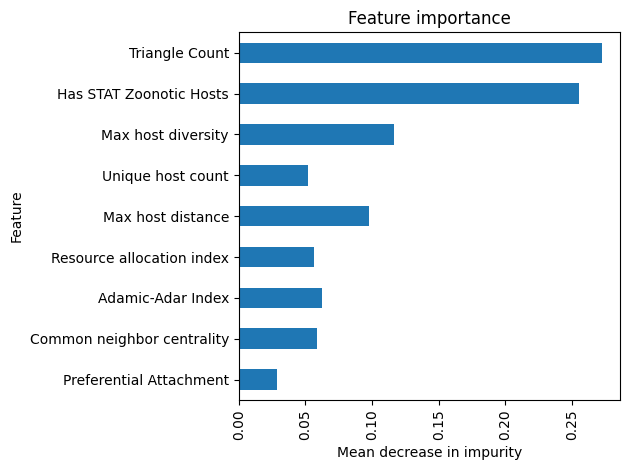

In [265]:
importances = classifiers[0].feature_importances_

forest_importances = pd.Series(importances, index=feature_names)
std = np.std([classifiers[0].feature_importances_ for tree in classifiers[0].estimators_], axis=0)

fig, ax = plt.subplots()
forest_importances.plot.barh(yerr=std, ax=ax)
ax.set_title("Feature importance")
ax.set_xlabel("Mean decrease in impurity")
ax.set_ylabel("Feature")
plt.xticks(rotation=90)

fig.tight_layout()

### GNN

In [34]:
### convert neo4j data to pyg graph (SOTU nodes, taxon nodes, edges)
### encode node features
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from torch_geometric.loader import LinkNeighborLoader
import torch

stat_threshold = 0.8
neo4j_data = get_neo4j_data(stat_threshold)
data = HeteroData()
mappings = {}

In [35]:
# SOTU node features: label encoded virus tax_id, num palmprints

sotu_df = neo4j_data['sotu_nodes']
sotu_mapping = {index: i for i, index in enumerate(sotu_df.appId.unique())}

sotu_df = sotu_df.merge(
    neo4j_data['sotu_num_palmprints'][['appId', 'numPalmprints']],
    on='appId',
    how='left'
)

sotu_tax_order_map =  {label: i for i, label in enumerate(sotu_df.taxOrder.unique())}
sotu_x = []

for i, row in sotu_df.iterrows():
    sotu_features = torch.tensor([
        row['taxId'],
        sotu_tax_order_map[row['taxOrder']],
        row['numPalmprints'],
    ])
    sotu_x.append(sotu_features)

sotu_x = torch.stack(sotu_x)
sotu_x = sotu_x.float()


data['sotu'].x = sotu_x
mappings['sotu'] = sotu_mapping

In [36]:
# Taxon node features: label encoded tax_id, label encoded hostClass

taxon_df = neo4j_data['taxon_order_nodes']
taxon_mapping = {index: i for i, index in enumerate(taxon_df.taxId.unique())}

host_class_label_map = {label: i for i, label in enumerate(taxon_df.hostClass.unique())}
taxon_order_map =  {label: i for i, label in enumerate(taxon_df.taxOrder.unique())}
taxon_x = []

for i, row in taxon_df.iterrows():
    taxon_features = torch.tensor([
        row['taxId'],
        host_class_label_map[row['hostClass']],
        taxon_order_map[row['taxOrder']]
    ])
    taxon_x.append(taxon_features)

taxon_x = torch.stack(taxon_x)
taxon_x = taxon_x.float()


data['taxon'].x = taxon_x
mappings['taxon'] = taxon_mapping

In [37]:
# SOTU has_host TAXON edges

sotu_has_host_df = neo4j_data['has_host_order_stat_edges']

src = [sotu_mapping[index] for index in sotu_has_host_df['sourceAppId']]
dst = [taxon_mapping[index] for index in sotu_has_host_df['targetAppId']]
edge_index = torch.tensor([src, dst])
edge_attr = []

for i, row in sotu_has_host_df.iterrows():
    edge_attr.append([
        row['count'],
        row['avgPercentIdentityPalmprint'],
        row['avgPercentIdentityStatKmers'],
        row['avgPercentIdentityStatSpots'],
        row['weight']
    ])

edge_attr = torch.tensor(edge_attr)
edge_attr = edge_attr.float()

data['sotu', 'has_host', 'taxon'].edge_index = edge_index
data['sotu', 'has_host', 'taxon'].edge_label = edge_attr

In [38]:
# SOTU sequence_similarity SOTU edges

sotu_msa_df = neo4j_data['sotu_msa_edges']
src = [sotu_mapping[index] for index in sotu_msa_df['sourceAppId']]
dst = [sotu_mapping[index] for index in sotu_msa_df['targetAppId']]
edge_index = torch.tensor([src, dst])
# edge_index = to_undirected(edge_index, num_nodes=len(sotu_mapping))

edge_attr = []
for i, row in sotu_msa_df.iterrows():
    edge_attr.append([row['percentIdentity']])

edge_attr = torch.tensor(edge_attr)
edge_attr = edge_attr.float()

data['sotu', 'sequence_similarity', 'sotu'].edge_index = edge_index
data['sotu', 'sequence_similarity', 'sotu'].edge_attr = edge_attr 

In [39]:
node_types, edge_types = data.metadata()
if not ('taxon', 'rev_has_host', 'sotu') in edge_types:
    data = T.ToUndirected()(data)
    # Remove "reverse" label. (redundant if using link loader)
    del data['taxon', 'rev_has_host', 'sotu'].edge_label

print(data)

In [ ]:
## Model
MODEL_CFG = {
    'PROJECTION_NAME': 'palmprint-host-dataset',
    'PIPELINE_NAME': 'lp-pipeline',
    'MODEL_NAME': 'lp-model',
    'RANDOM_SEED': 42,
    'TEST_FRACTION': 0.3,
    'TRAIN_FRACTION': 0.6,
    'VALIDATION_FOLDS': 10,
    'MIN_EPOCHS': 1,
    'MAX_EPOCHS': 100,
    'LR': 0.001,
    'PREDICTION_THRESHOLD': 0.2,
}

In [ ]:
## Data loaders

def split_data(data):
    num_test = (1 - MODEL_CFG['TRAIN_FRACTION']) * MODEL_CFG['TEST_FRACTION']
    num_val = 1 - MODEL_CFG['TRAIN_FRACTION'] - num_test

    transform = T.RandomLinkSplit(
        # Link-level split train (80%), validate (10%), and test edges (10%)
        num_val=num_val,
        num_test=num_test,
        # Of training edges, use 70% for message passing (edge_index)
        # and 30% for supervision (edge_label_index)
        disjoint_train_ratio=0.3,
        # Generate fixed negative edges for evaluation with a ratio of 2-1.
        # Negative edges during training will be generated on-the-fly.
        neg_sampling_ratio=MODEL_CFG['NEGATIVE_SAMPLING_RATIO'],
        add_negative_train_samples=False,
        edge_types=('sotu', 'has_host', 'taxon'),
        rev_edge_types=('taxon', 'rev_has_host', 'sotu'),
    )
    train_data, val_data, test_data = transform(data)
    return train_data, val_data, test_data


def get_train_loader(train_data, batch_size=2048):
    # Define mini-batch loaders
    edge_label_index = train_data[(
        'sotu', 'has_host', 'taxon')].edge_label_index

    train_loader = LinkNeighborLoader(
        data=train_data,
        # In the first hop, we sample at most 20 neighbors.
        # In the second hop, we sample at most 10 neighbors.
        num_neighbors=[8, 4],
        # neg_sampling_ratio=MODEL_CFG['NEGATIVE_SAMPLING_RATIO'],
        neg_sampling='binary',
        # let 'binary' setting handle this
        # edge_label=train_data[('sotu', 'has_host', 'taxon')].edge_label,
        edge_label_index=(('sotu', 'has_host', 'taxon'),
                          edge_label_index),
        batch_size=batch_size,
        shuffle=True,
        # num_workers=4,
    )
    return train_loader


def get_val_loader(val_data, batch_size=2048):
    # Define the validation seed edges:
    edge_label_index = val_data['sotu',
                                'has_host', 'taxon'].edge_label_index
    edge_label = val_data['sotu', 'has_host', 'taxon'].edge_label

    val_loader = LinkNeighborLoader(
        data=val_data,
        num_neighbors=[8, 4],
        edge_label_index=(('sotu', 'has_host', 'taxon'),
                          edge_label_index),
        edge_label=edge_label,
        batch_size=batch_size,
        shuffle=False,
        # num_workers=4,
    )
    return val_loader


In [ ]:
## Training and testing

class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False


def train(model, train_loader, optimizer, device):
    model.train()
    total_loss = total_examples = 0
    total_neg = 0
    total = 0
    for batch in train_loader:
        labels = batch['sotu', 'taxon'].edge_label
        total_neg += torch.count_nonzero(labels).item()
        total += labels.numel()

        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(
            batch.x_dict,
            batch.edge_index_dict,
            batch['sotu', 'taxon'].edge_label_index)

        target = batch['sotu', 'taxon'].edge_label.float()
        loss = F.binary_cross_entropy_with_logits(pred, target)
        loss.backward()
        optimizer.step()

        total_loss += float(loss)
        total_examples += pred.numel()

    return total_loss / total_examples


@torch.no_grad()
def test(model, loader, device):
    model.eval()

    preds, targets = [], []
    for batch in loader:
        batch = batch.to(device)

        pred = model(
            batch.x_dict,
            batch.edge_index_dict,
            batch['sotu', 'taxon'].edge_label_index
        ).sigmoid().view(-1).cpu()
        target = batch['sotu', 'taxon'].edge_label.cpu()

        preds.append(pred)
        targets.append(target)

    pred = torch.cat(preds, dim=0).numpy()
    target = torch.cat(targets, dim=0).numpy()

    # accuracy = accuracy_score(target, pred)
    # print(f"Accuracy: {accuracy:.4f}")

    # auc_roc = roc_auc_score(target, pred)
    # print(f"Validation AUC-ROC: {auc_roc:.4f}")

    auc_pr = average_precision_score(target, pred)
    # print(f"Validation AUC-PR: {auc_pr:.4f}")
    return auc_pr


def update_stats(training_stats, epoch_stats):
    if training_stats is None:
        training_stats = {}
        for key in epoch_stats.keys():
            training_stats[key] = []
    for key, val in epoch_stats.items():
        training_stats[key].append(val)
    return training_stats


def train_and_eval_loop(model, train_loader, val_loader, test_loader):
    early_stopper = EarlyStopper(patience=3, min_delta=10)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    training_stats = None

    for epoch in range(1, MODEL_CFG['MAX_EPOCHS']):
        train_loss = train(model, train_loader, optimizer, device)
        train_acc = test(model, test_loader, device)
        val_acc = test(model, val_loader, device)
        epoch_stats = {'train_acc': train_acc, 'val_acc': val_acc,
                       'train_loss': train_loss, 'epoch': epoch}
        training_stats = update_stats(training_stats, epoch_stats)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}")
            print(f"Train loss: {train_loss:.4f}")
            print(f"Train accuracy: {train_acc:.4f}")
            print(f"Validation accuracy: {val_acc:.4f}")

        if epoch > MODEL_CFG['MIN_EPOCHS'] \
                and early_stopper.early_stop(val_acc):
            break
    return training_stats

In [ ]:
model = 

### Graphistry visualizations


In [311]:
# Create node and relationship dataframes with full information
def get_graphistry_df(
        neo4j_data, communities, page_ranks_sotu, louvain
    ):
    neo4j_data['sotu_nodes']  = neo4j_data['sotu_nodes'].merge(
        merged_dropna[['TaxIDInt', 'vVirusNameDisplay']],
        left_on='taxId',
        right_on='TaxIDInt',
    )
    # neo4j_data['sotu_nodes']['displayLabel'] = neo4j_data['sotu_nodes']['vVirusNameDisplay']
    neo4j_data['sotu_nodes']['displayLabel'] = neo4j_data['sotu_nodes']['appId']
    neo4j_data['taxon_order_nodes']['displayLabel'] = neo4j_data['taxon_order_nodes']['taxOrder']
    neo4j_data['sotu_nodes']['type'] = 'SOTU'
    neo4j_data['taxon_order_nodes']['type'] = 'Taxon'

    nodes = pd.concat([
        neo4j_data['sotu_nodes'],
        neo4j_data['taxon_order_nodes'],
    ])
    nodes = nodes.merge(
        communities,
        left_on='nodeId',
        right_on='nodeId',
        how='left',
    )
    nodes = nodes.merge(
        page_ranks_sotu,
        left_on='nodeId',
        right_on='nodeId',
        how='left',
    )
    nodes = nodes.merge(
        louvain,
        left_on='nodeId',
        right_on='nodeId',
        how='left',
    )

    nodes = nodes[[
        'appId', 'labels', 'type',
        'taxId', 'isZoonotic', 'hostClass',
        'taxRank', 'communityId',
        'taxOrder', 'displayLabel',
        'pageRankSotu', 'louvainCommunityId',
    ]].astype(str)

    # Encode zoonotic status to use default color pallette
    nodes['zoonoticColorCodes'] = nodes['isZoonotic'].replace({'True': 1, 'False': 0, 'nan': 2 })
    nodes['zoonoticColorCodes'] = nodes['zoonoticColorCodes'].astype('int32')


    # Encode communityId to use default color pallette
    nodes['communityId'] = nodes['communityId'].astype('float64')
    nodes['communityId'] = nodes['communityId'].fillna(-1)
    nodes['communityId'] = nodes['communityId'].astype('int32')
    labels = nodes['communityId'].unique()
    mapping = {label: i for i, label in enumerate(labels)}
    nodes['communityId'] =  nodes['communityId'].replace(mapping)
    nodes['communityColorCodes'] = nodes['communityId'].mod(11)


    # Add host counts for palmprints
    stat_hosts_excl_mixed = neo4j_data['has_host_order_stat_edges'][neo4j_data['has_host_order_stat_edges']['targetAppId'] != 12908]
    host_counts = stat_hosts_excl_mixed.groupby('sourceAppId').size().groupby(level=0).max()
    # host_counts = neo4j_data['has_host_order_stat_edges'].groupby('sourceAppId').size().groupby(level=0).max()
    host_counts = host_counts.reset_index()
    host_counts = host_counts.rename({0: 'hostCount'}, axis='columns')
    host_counts['hostCountNormalized'] = round((host_counts['hostCount'] / host_counts['hostCount'].max()) * 100, -1).astype('int32')
    nodes = nodes.merge(
        host_counts,
        left_on='appId',
        right_on='sourceAppId',
        how='left',
    )

    relationships = pd.concat([
        neo4j_data['sotu_msa_edges'],
        neo4j_data['has_host_order_stat_edges'],
    ])
    
    relationships['targetAppId'] = relationships['targetAppId'].astype(str)
    relationships['sourceAppId'] = relationships['sourceAppId'].astype(str)

    relationships['weight'] = relationships['weight'].astype(float)
    relationships['weightInt'] = round(relationships['weight'] * 100, -1).astype('int32')
    relationships = relationships[[
        'sourceAppId', 'targetAppId', 'relationshipType', 
        'weight', 'weightInt',
    ]].astype(str)
    relationships['weightInt'] = relationships['weightInt'].astype('int32')
    return nodes, relationships



def load_or_create_graphistry_df(stat_threshold, node_filename, relationship_filename, use_cache=False):
    if use_cache and os.path.exists(graphistry_data_path + node_filename) \
            and os.path.exists(graphistry_data_path + relationship_filename):
        nodes = pd.read_csv(graphistry_data_path + node_filename)
        edges = pd.read_csv(graphistry_data_path + relationship_filename)
    else:
        neo4j_data = get_neo4j_data(stat_threshold)
        G = construct_gds_projection(neo4j_data)
        communities, wcc, page_ranks_sotu, louvain = run_community_analysis(G)
        # binary_pvals, multi_pvals = run_pval_analysis(neo4j_data)
        nodes, edges = get_graphistry_df(
            neo4j_data, communities, page_ranks_sotu, louvain
        )
        nodes.to_csv(graphistry_data_path + node_filename, index=False)
        edges.to_csv(graphistry_data_path + relationship_filename, index=False)
    return nodes, edges


In [316]:
stat_threshold = 0.8
nodes, relationships = load_or_create_graphistry_df(stat_threshold, 'nodes.csv', 'edges.csv', False)
# nodes, relationships = load_or_create_graphistry_df('nodes_v2.csv', 'edges_v2.csv')

0.8
sotu_nodes:  (742, 8)
sotu_msa_edges:  (2714, 7)
taxon_order_nodes:  (185, 7)
has_host_order_stat_edges:  (1067, 10)
has_host_metadata_label:  (11558, 8)
sotu_sra_bioproject_counts:  (700, 4)

LPA Unique communities: 438
LPA Most common communities: [(8170199, 45), (7858962, 39), (7743098, 27), (7935516, 20), (7999668, 15), (7971675, 13), (7714332, 12), (8100725, 12), (7994679, 12), (8017721, 10)]
WCC Unique communities: 397
WCC Most common communities: [(431, 86), (2, 42), (0, 40), (5, 23), (34, 17), (41, 15), (1, 14), (106, 14), (649, 12), (674, 11)]
Louvain Unique communities: 387
Louvain Most common communities: [(435, 51), (208, 43), (163, 40), (604, 35), (5, 23), (126, 17), (188, 16), (80, 16), (193, 15), (24, 14)]


In [317]:
alt_color_pallete = [
    "rgb(166, 206, 227)",
    "rgb(31, 120, 180)",
    "rgb(178, 223, 138)",
    "rgb(51, 160, 44)",
    "rgb(251, 154, 153)",
    "rgb(227, 26, 28)",
    "rgb(253, 191, 111)",
    "rgb(255, 127, 0)",
    "rgb(202, 178, 214)",
    "rgb(106, 61, 154)",
    "rgb(255, 255, 153)", 
    "#ffffff",
]

categorical_colors = {}

for communityId in nodes.communityColorCodes.unique():
    categorical_colors[str(communityId)] = alt_color_pallete[communityId % len(alt_color_pallete)]

categorical_colors[11] = "#808080"

# for i, row in nodes.iterrows():
#     if row['hostCount'] > 1:
#         nodes.at[i,'communityColorCodes'] = 11

In [318]:
g = graphistry.bind()

g = g.bind(
    source='sourceAppId',
    destination='targetAppId',
    edge_weight='weight',
).edges(relationships)

g = g.bind(
    node='appId',
    point_label='displayLabel',
    point_size=None,
    # point_size='statCoverageInt',
).nodes(nodes)


params = {
        'play': 2000,
        'menu': True, 
        'info': True,
        'showArrows': True,
        'pointSize': 2.0, 
        # 'edgeCurvature': 0.5,
        'edgeOpacity': 0.25, 
        'pointOpacity': 1.0,
        # 'lockedX': False, 'lockedY': False, 'lockedR': False,
        'linLog': True, 
        'compactLayout': True,
        'strongGravity': True,
        'dissuadeHubs': False,
        'edgeInfluence': 5,
        # 'precisionVsSpeed': 0, 'gravity': 1.0, 'scalingRatio': 1.0,
        # 'showLabels': True, 'showLabelOnHover': True,
        # 'showPointsOfInterest': True, 'showPointsOfInterestLabel': True, 
        'showLabelPropertiesOnHover': True,
        'pointsOfInterestMax': 10,
      }

g = g.settings(url_params=params)


g = g.addStyle(
    bg={
        'color': 'black',
})

# g = g.encode_point_color(
#     'communityColorCodes',
#     categorical_mapping=categorical_colors,
# )


g = g.encode_point_color(
    'zoonoticColorCodes',
    categorical_mapping={0: 'rgb(10, 228, 108)', 1: 'rgb(228, 108, 10)', 2: 'rgb(108, 10, 228)'},
)

g.plot()

Error: <Response [400]>
Traceback (most recent call last):
  File "/Users/lukepereira/anaconda3/envs/rnalab/lib/python3.11/site-packages/graphistry/arrow_uploader.py", line 362, in refresh
    raise Exception(out.text)
Exception: {"non_field_errors":["Token has expired."]}

In [ ]:
print(urllib.parse.urlencode(params))

-
